In [49]:
library(MatchIt)
library(tidyverse)
library(cobalt)

Warning message:
"package 'cobalt' was built under R version 4.4.3"
 cobalt (Version 4.6.1, Build Date: 2025-08-20)


Attaching package: 'cobalt'


The following object is masked from 'package:MatchIt':

    lalonde




In [2]:
df <- read.csv("./df.csv")
df <- df %>% drop_na(start_temp)

In [33]:
match <- matchit(
    type ~ elevation + slope + lights,
    data = df,
    method = "nearest",
    caliper = 0.02,
    distance = "glm",
    link="probit"
)

In [34]:
summary(match)


Call:
matchit(formula = type ~ elevation + slope + lights, data = df, 
    method = "nearest", distance = "glm", link = "probit", caliper = 0.02)

Summary of Balance for All Data:
          Means Treated Means Control Std. Mean Diff. Var. Ratio eCDF Mean
distance         0.2965        0.2845          0.2146     1.5883    0.0597
elevation      856.4912      849.3794          0.0723     1.7057    0.0332
slope            2.1579        1.9645          0.1449     1.6155    0.0370
lights          34.4817       33.1595          0.1103     1.4258    0.0480
          eCDF Max
distance    0.1232
elevation   0.0789
slope       0.0939
lights      0.1230

Summary of Balance for Matched Data:
          Means Treated Means Control Std. Mean Diff. Var. Ratio eCDF Mean
distance         0.2853        0.2853          0.0010     1.0023    0.0032
elevation      845.7955      846.8182         -0.0104     1.1949    0.0395
slope            2.0000        2.0568         -0.0426     1.0308    0.0146
lights     

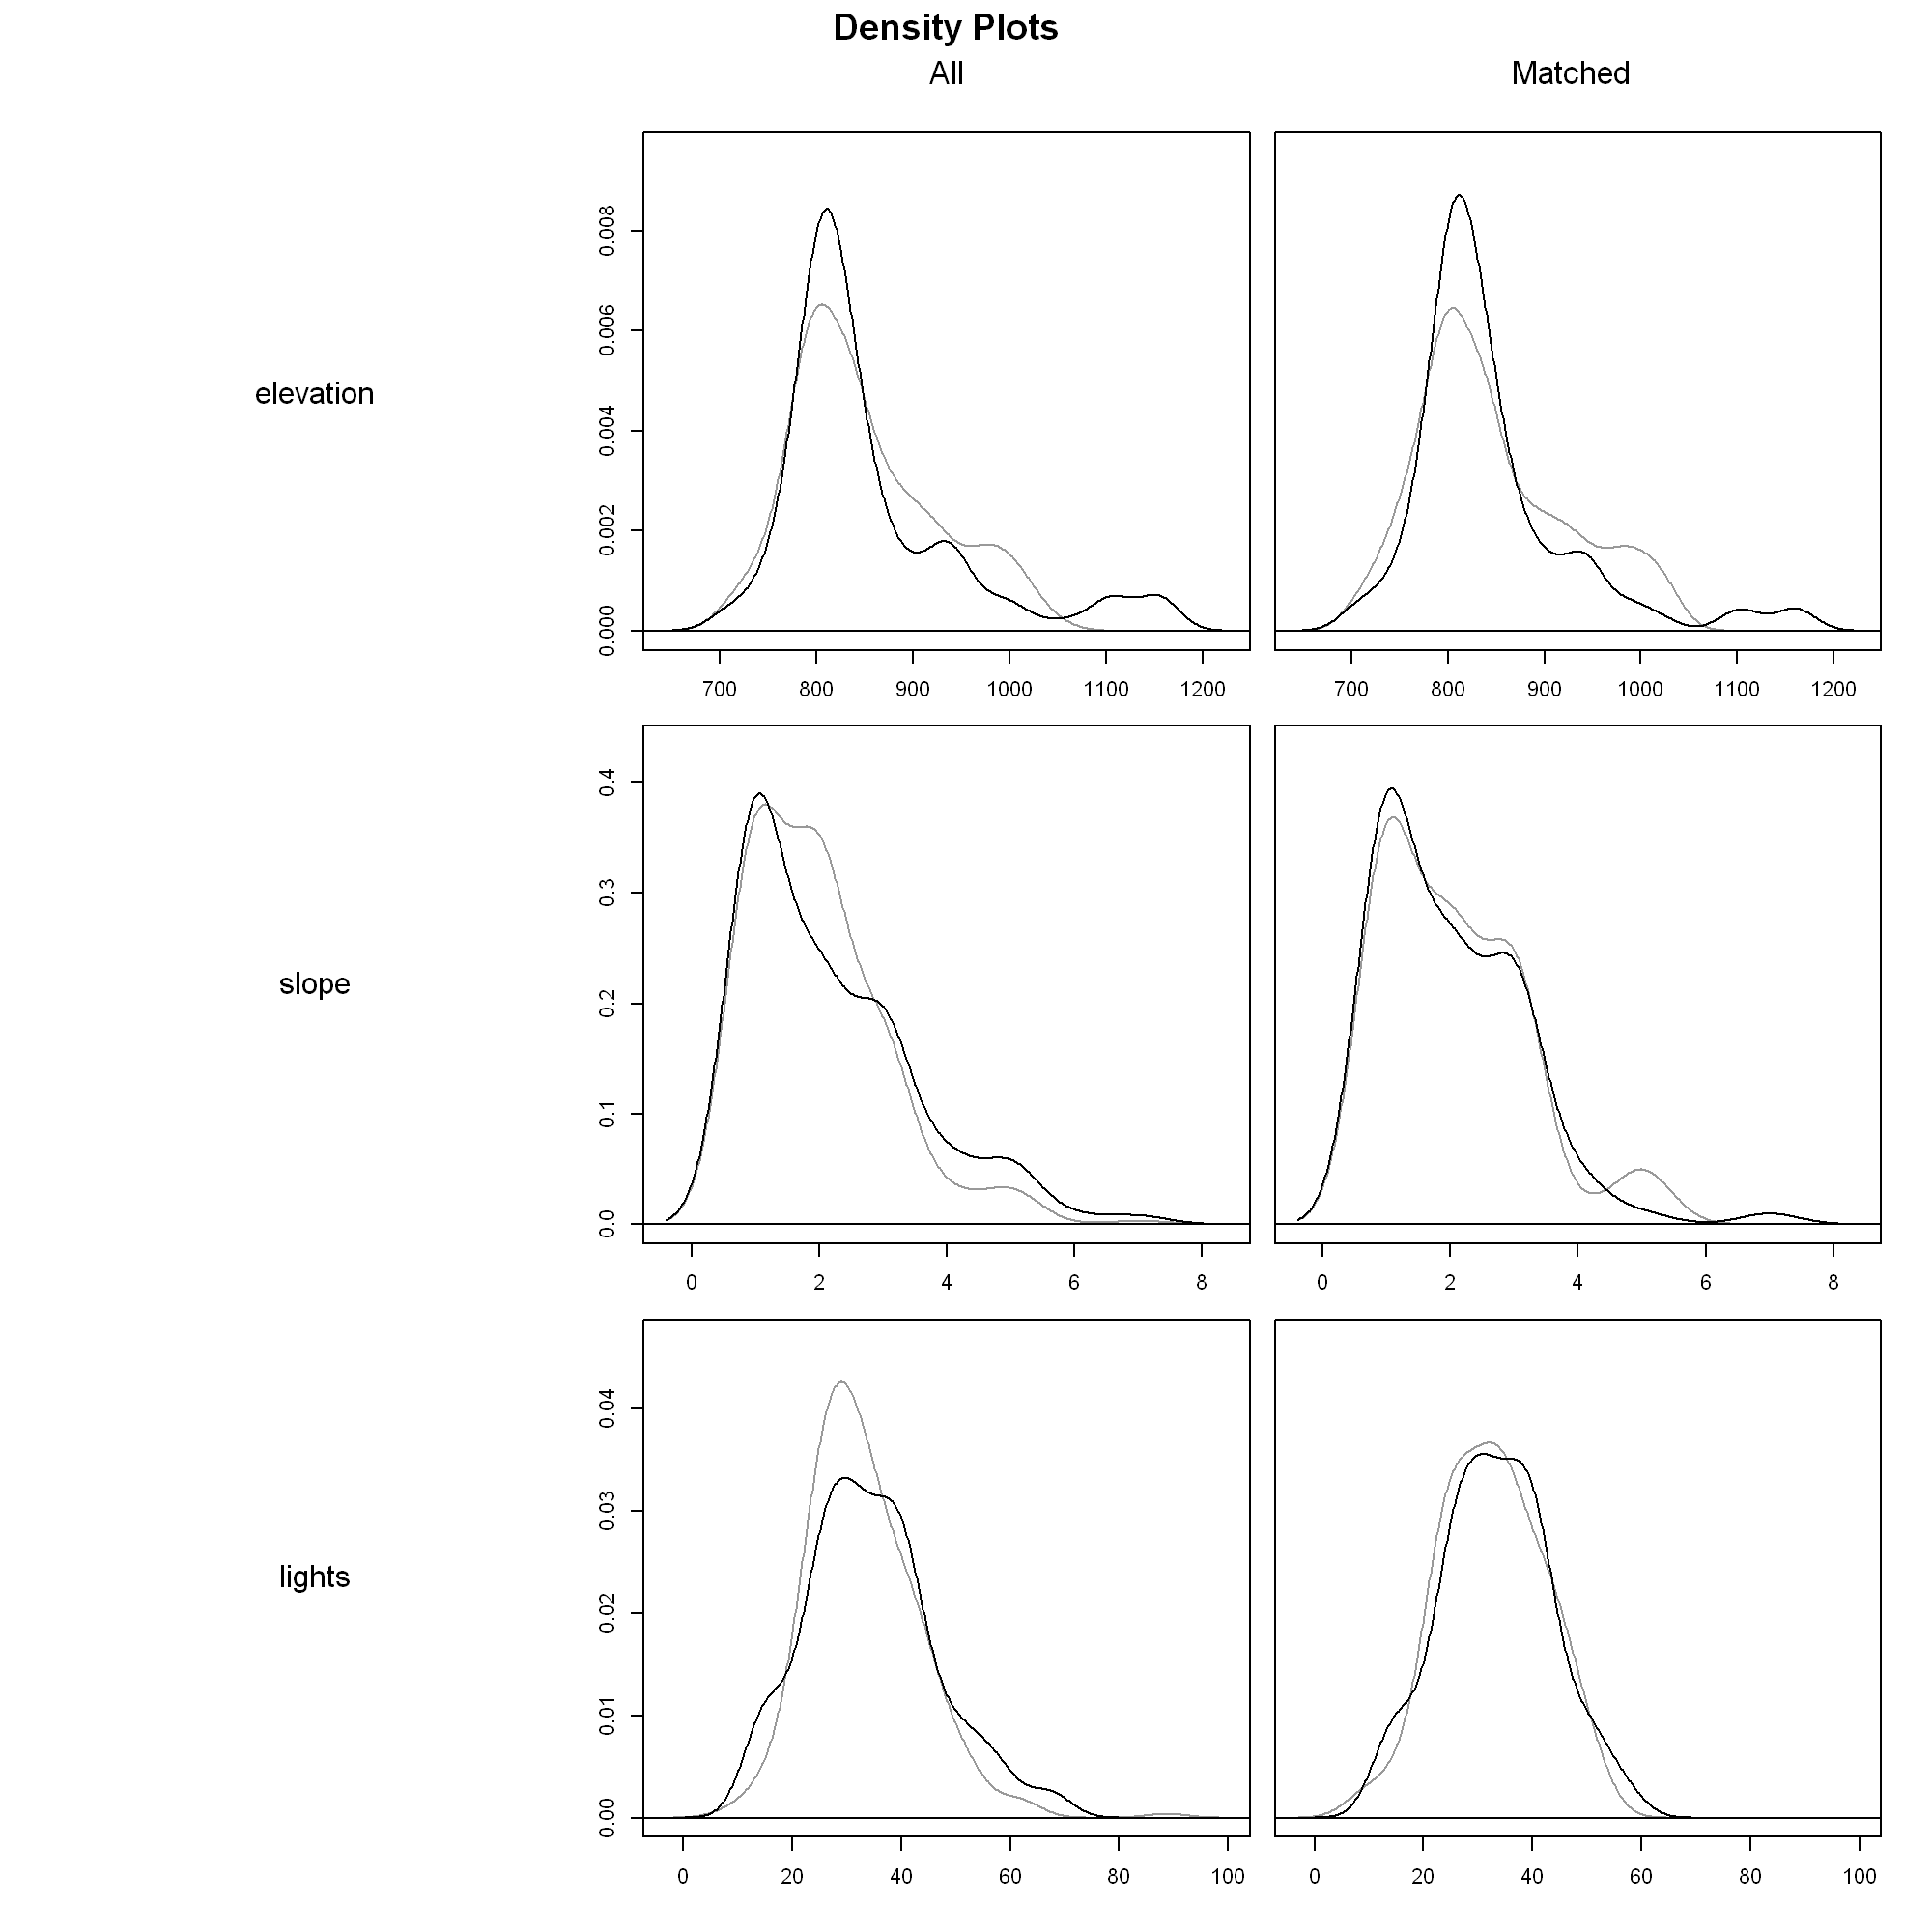

In [53]:
par(bg = 'white')
options(repr.plot.width=10, repr.plot.height=10, repr.plot.res=200)
plot(match, type="density", interactive=FALSE)

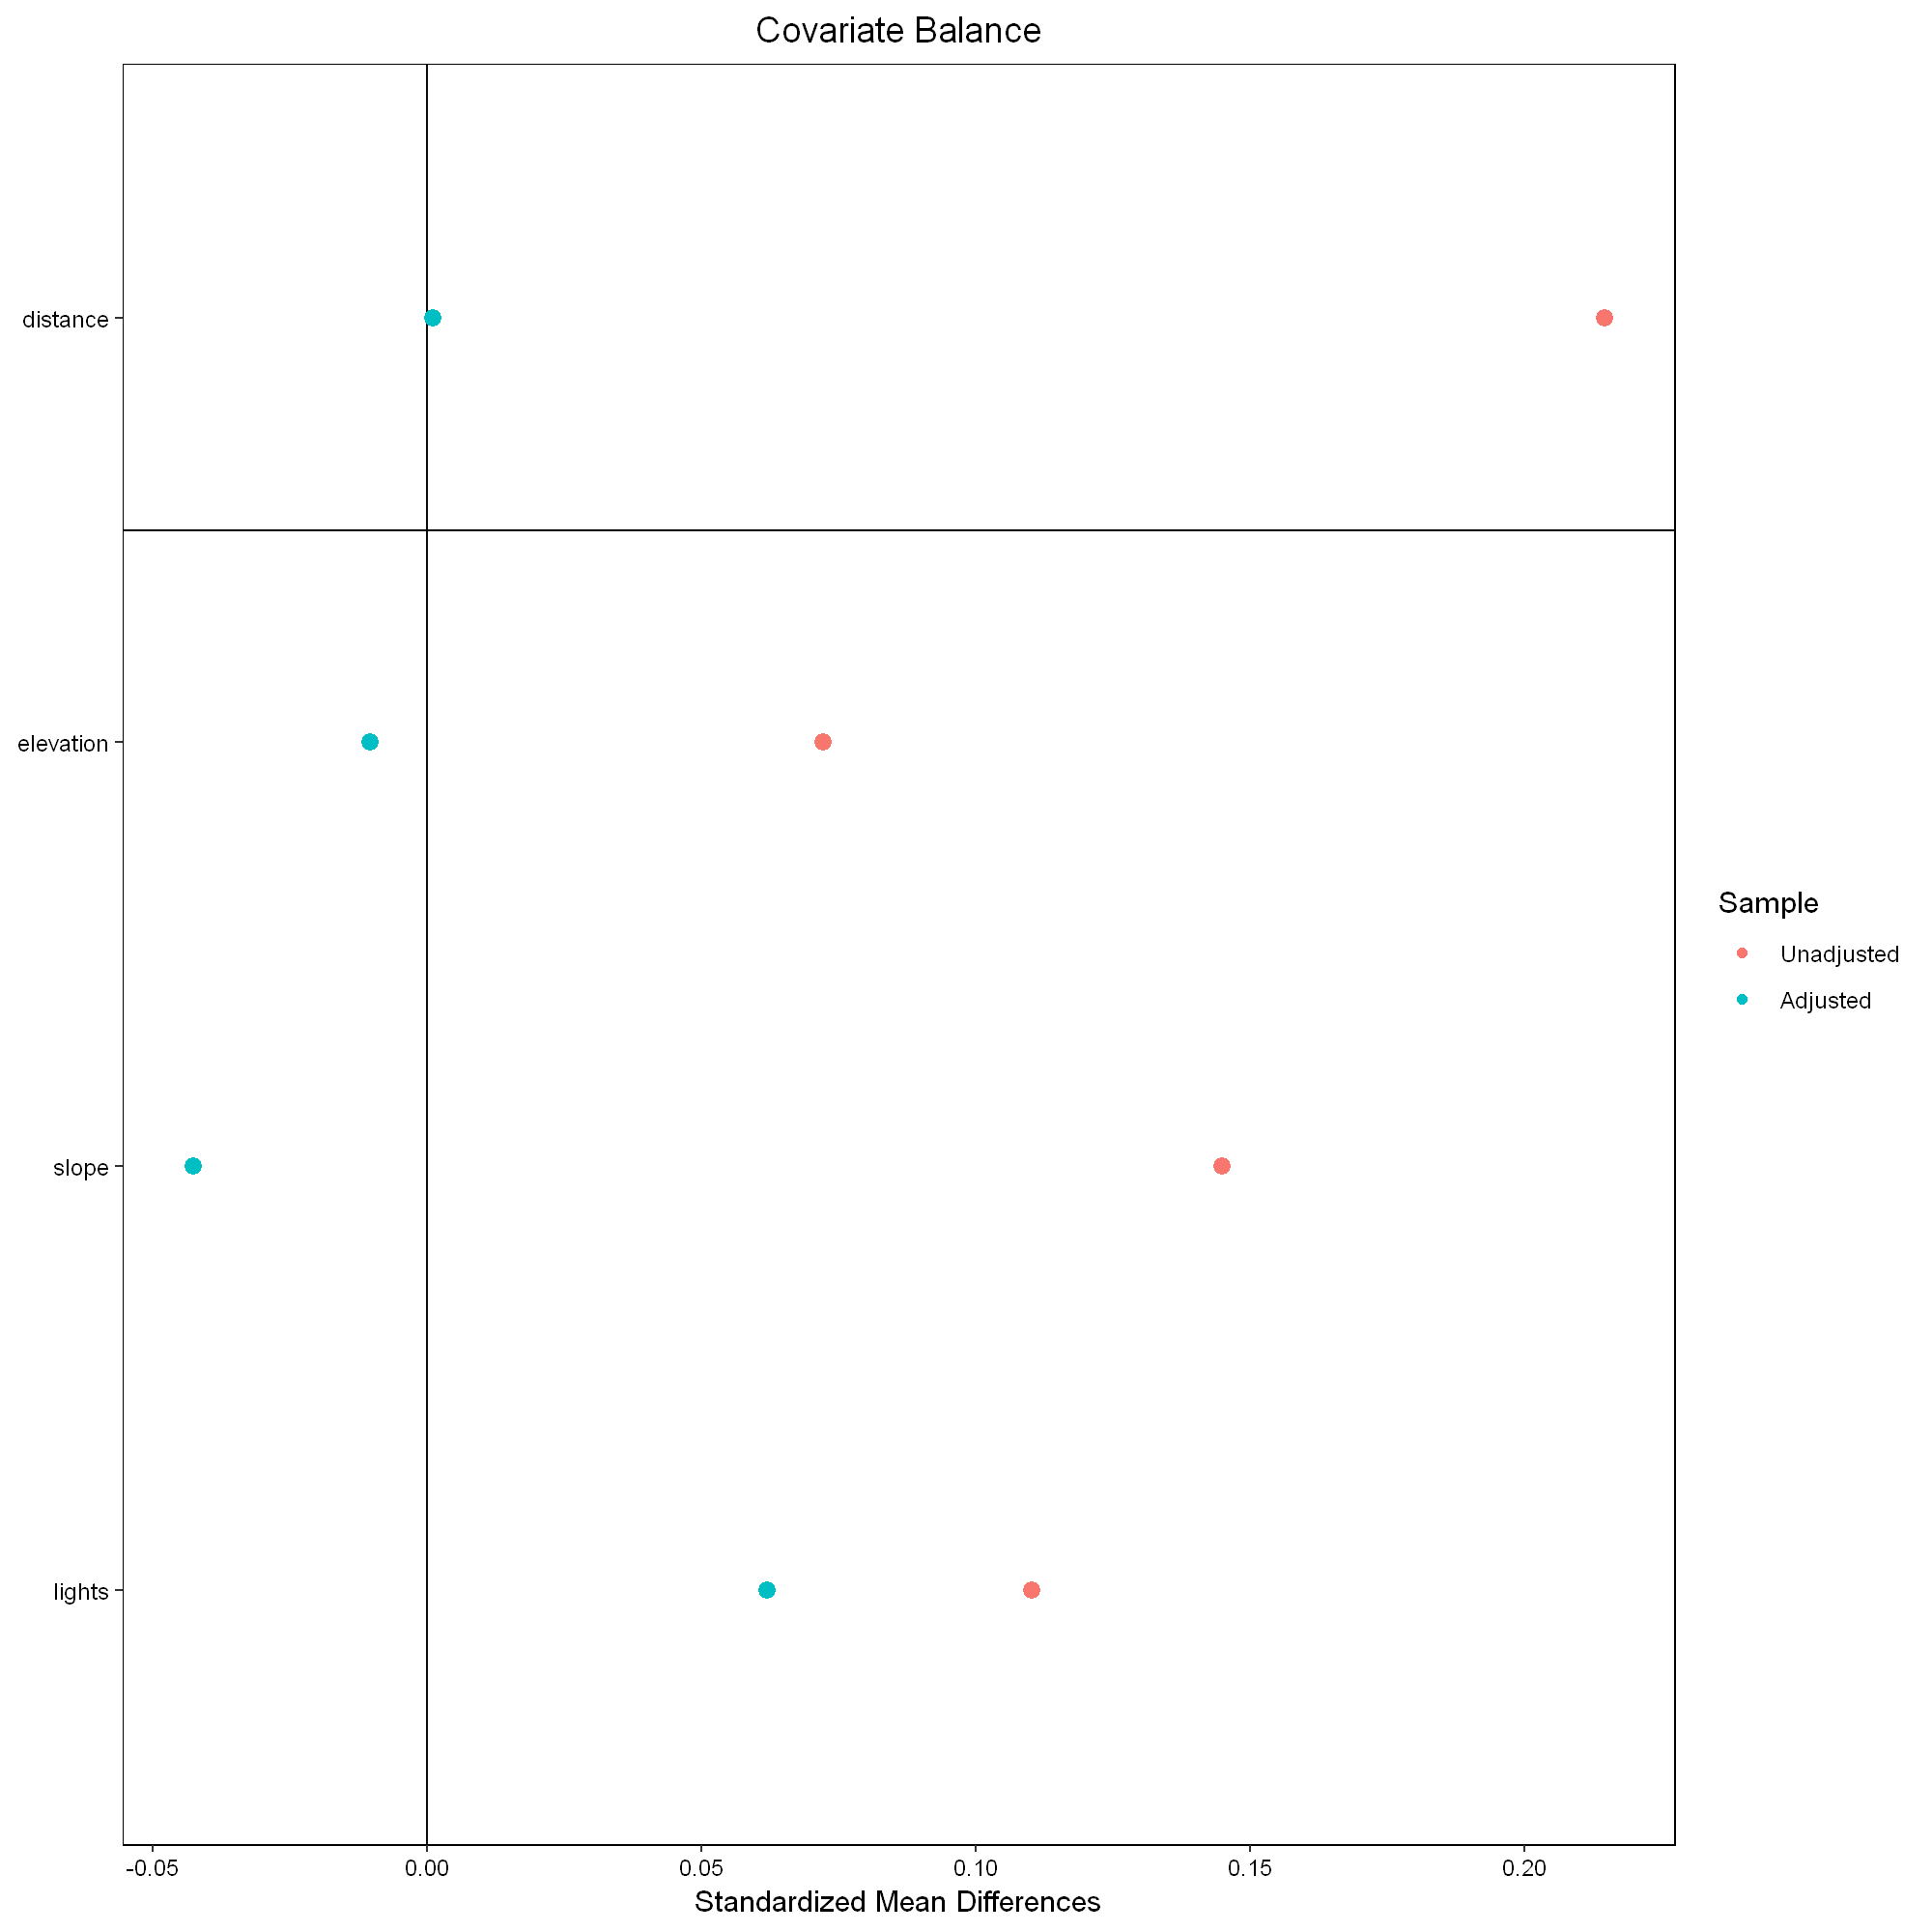

In [54]:
options(repr.plot.res=200)
love.plot(match)

In [56]:
vignette("assessing-balance")

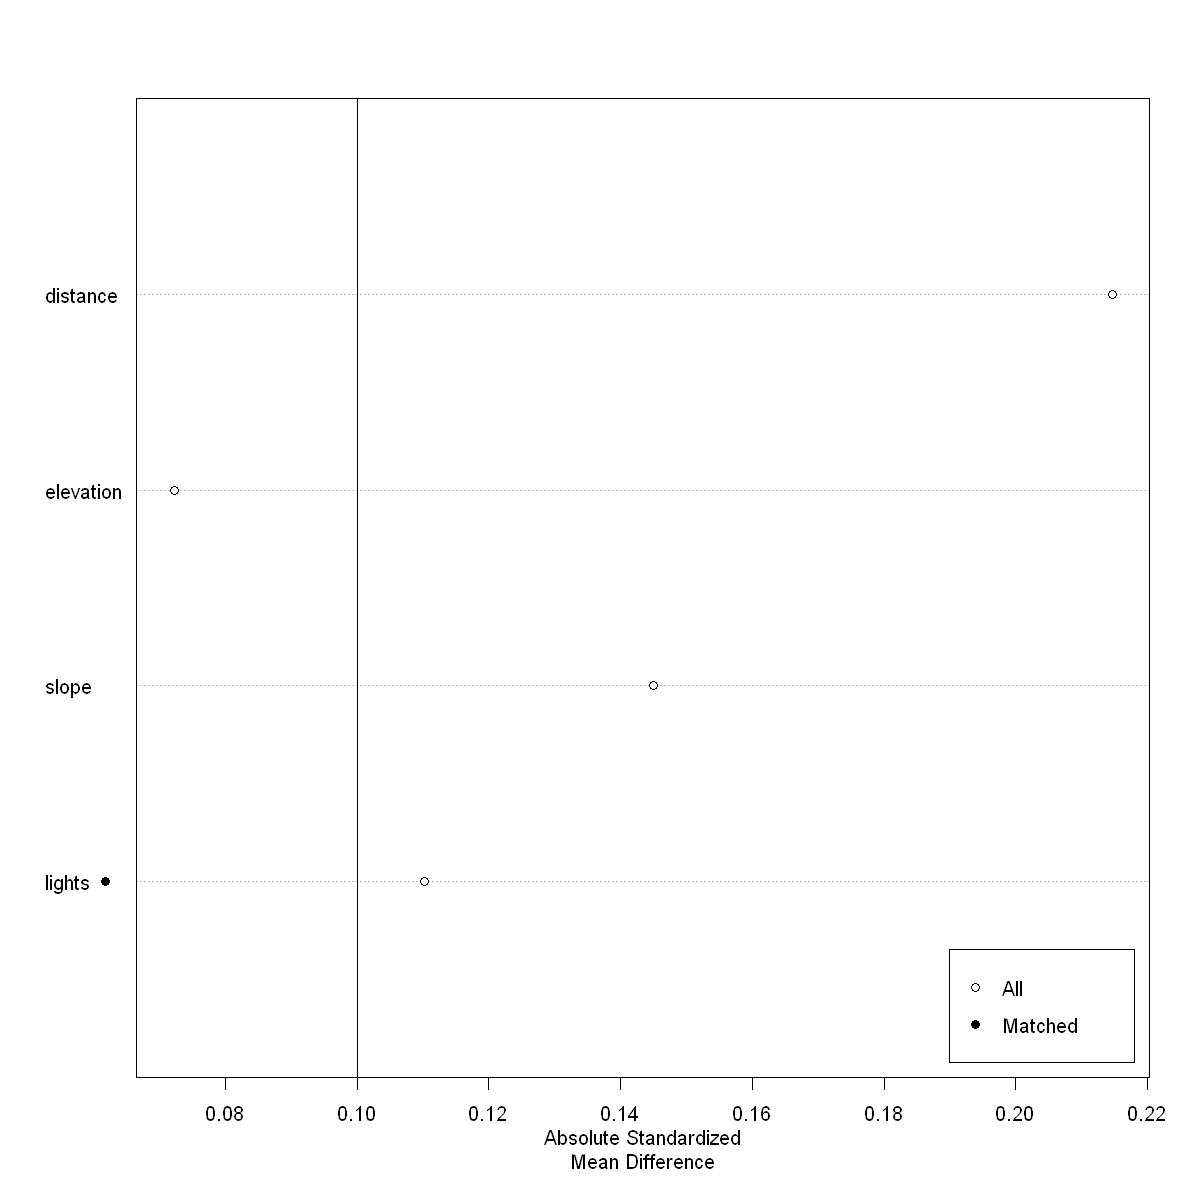

In [45]:
par(bg = 'white')
options(repr.plot.width=10, repr.plot.height=10)
plot(summary(match))